# A Framework for Leveraging LLMs for Scene Analysis and Cognitive Processing

In [ ]:
!pip install Levenshtein
!pip install nltk       

In [1]:
import os
HOME = os.getcwd()

os.chdir(HOME)
print(HOME)

d:\home\Documents\Github\human_patterns_exploration


In [2]:
HOME = os.getcwd()
os.chdir(HOME)

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")


In [3]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
from src.models.KG import KnowledgeGraph
import os
import pickle

from src.utils.data_utils import load_image_data

import pandas as pd
pd.set_option('display.max_rows', None)

import pandas as pd  



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


NLTK data downloaded successfully!


### Checking the bounding boxes for all participants

In [4]:
IMG_ID = 1
IMG_TYPE = "exp"
llm_provider = "openai"

# load image
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")
image_data = load_image_data(IMG_PATH, IMG_TYPE, target = [430, 510, 545, 595])


# load masks
masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")
image_data.load_img_masks( masks_path_dir, part_id=None )
print(f"Loaded a total of {len(image_data.masks)} Masks for IMG {image_data.ID}_{image_data.img_type}")

Loaded a total of 63 Masks for IMG 1_exp


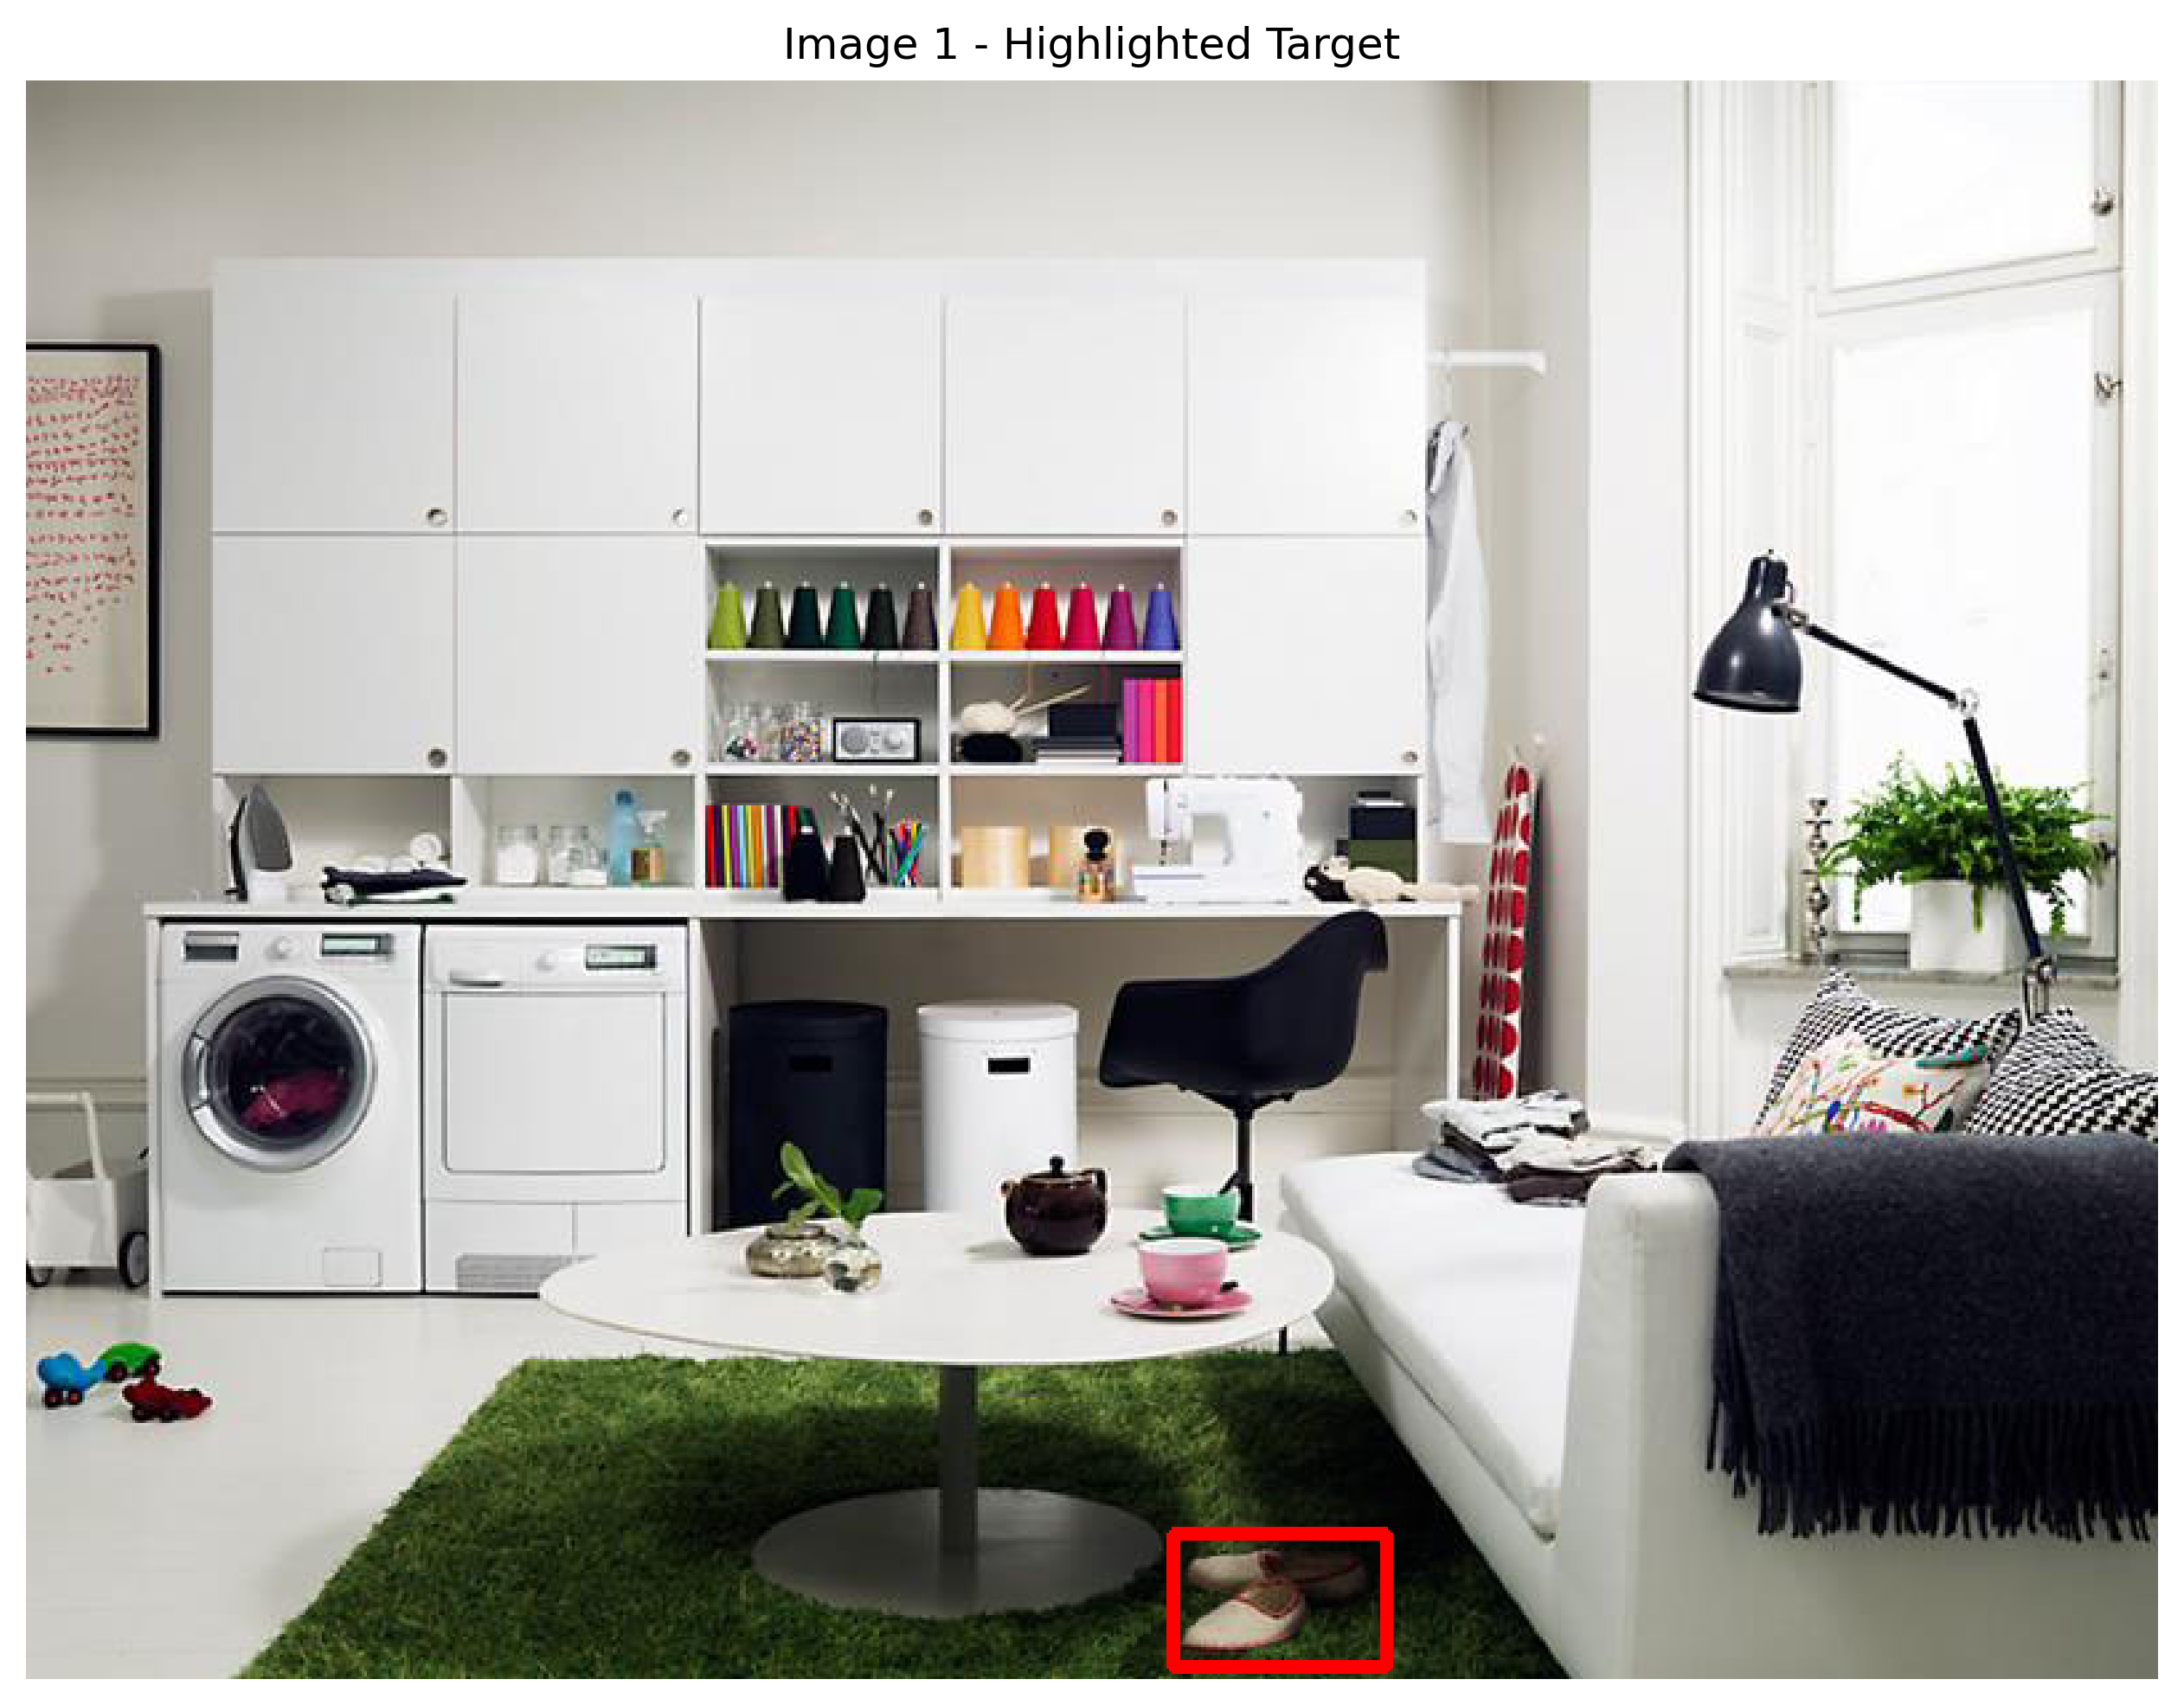

In [5]:
image_data.highlight_target();

In [6]:
image_data.get_scene_masks()

  -> Lemma match! Removing 'slippers', keeping 'slipper'
  -> Lemma match! Removing 'toys', keeping 'toy'

Plural/duplicate pairs found: [('slipper', 'slippers', 'kept: slipper'), ('toy', 'toys', 'kept: toy')]
Final unique labels: ['cabinets', 'cart', 'chair', 'clothes', 'cup', 'cushion', 'desk', 'hamper', 'ironing', 'lamp', 'laundry', 'plant', 'rug', 'shelves', 'shoe', 'slipper', 'sofa', 'table', 'teapot', 'throw', 'toy']


{'cabinets': [350.0, 376.0, 280.0, 303.0],
 'cart': [0.0, 45.0, 379.0, 453.0],
 'chair': [464.0, 537.0, 312.0, 402.0],
 'clothes': [525.0, 610.0, 379.0, 413.0],
 'cup': [417.0, 451.0, 434.0, 459.0],
 'cushion': [520.0, 552.0, 397.0, 413.0],
 'desk': [44.0, 537.0, 302.0, 339.0],
 'hamper': [261.0, 323.0, 345.0, 429.0],
 'ironing': [524.0, 549.0, 127.0, 287.0],
 'lamp': [570.0, 637.0, 0.0, 393.0],
 'laundry': [520.0, 613.0, 380.0, 423.0],
 'plant': [281.0, 321.0, 61.0, 270.0],
 'rug': [80.0, 574.0, 476.0, 599.0],
 'shelves': [70.0, 525.0, 69.0, 304.0],
 'shoe': [434.0, 480.0, 561.0, 589.0],
 'slipper': [434.0, 480.0, 561.0, 589.0],
 'sofa': [471.0, 584.0, 403.0, 545.0],
 'table': [191.0, 489.0, 422.0, 577.0],
 'teapot': [366.0, 405.0, 404.0, 441.0],
 'throw': [615.0, 799.0, 395.0, 547.0],
 'toy': [4.0, 51.0, 473.0, 497.0]}

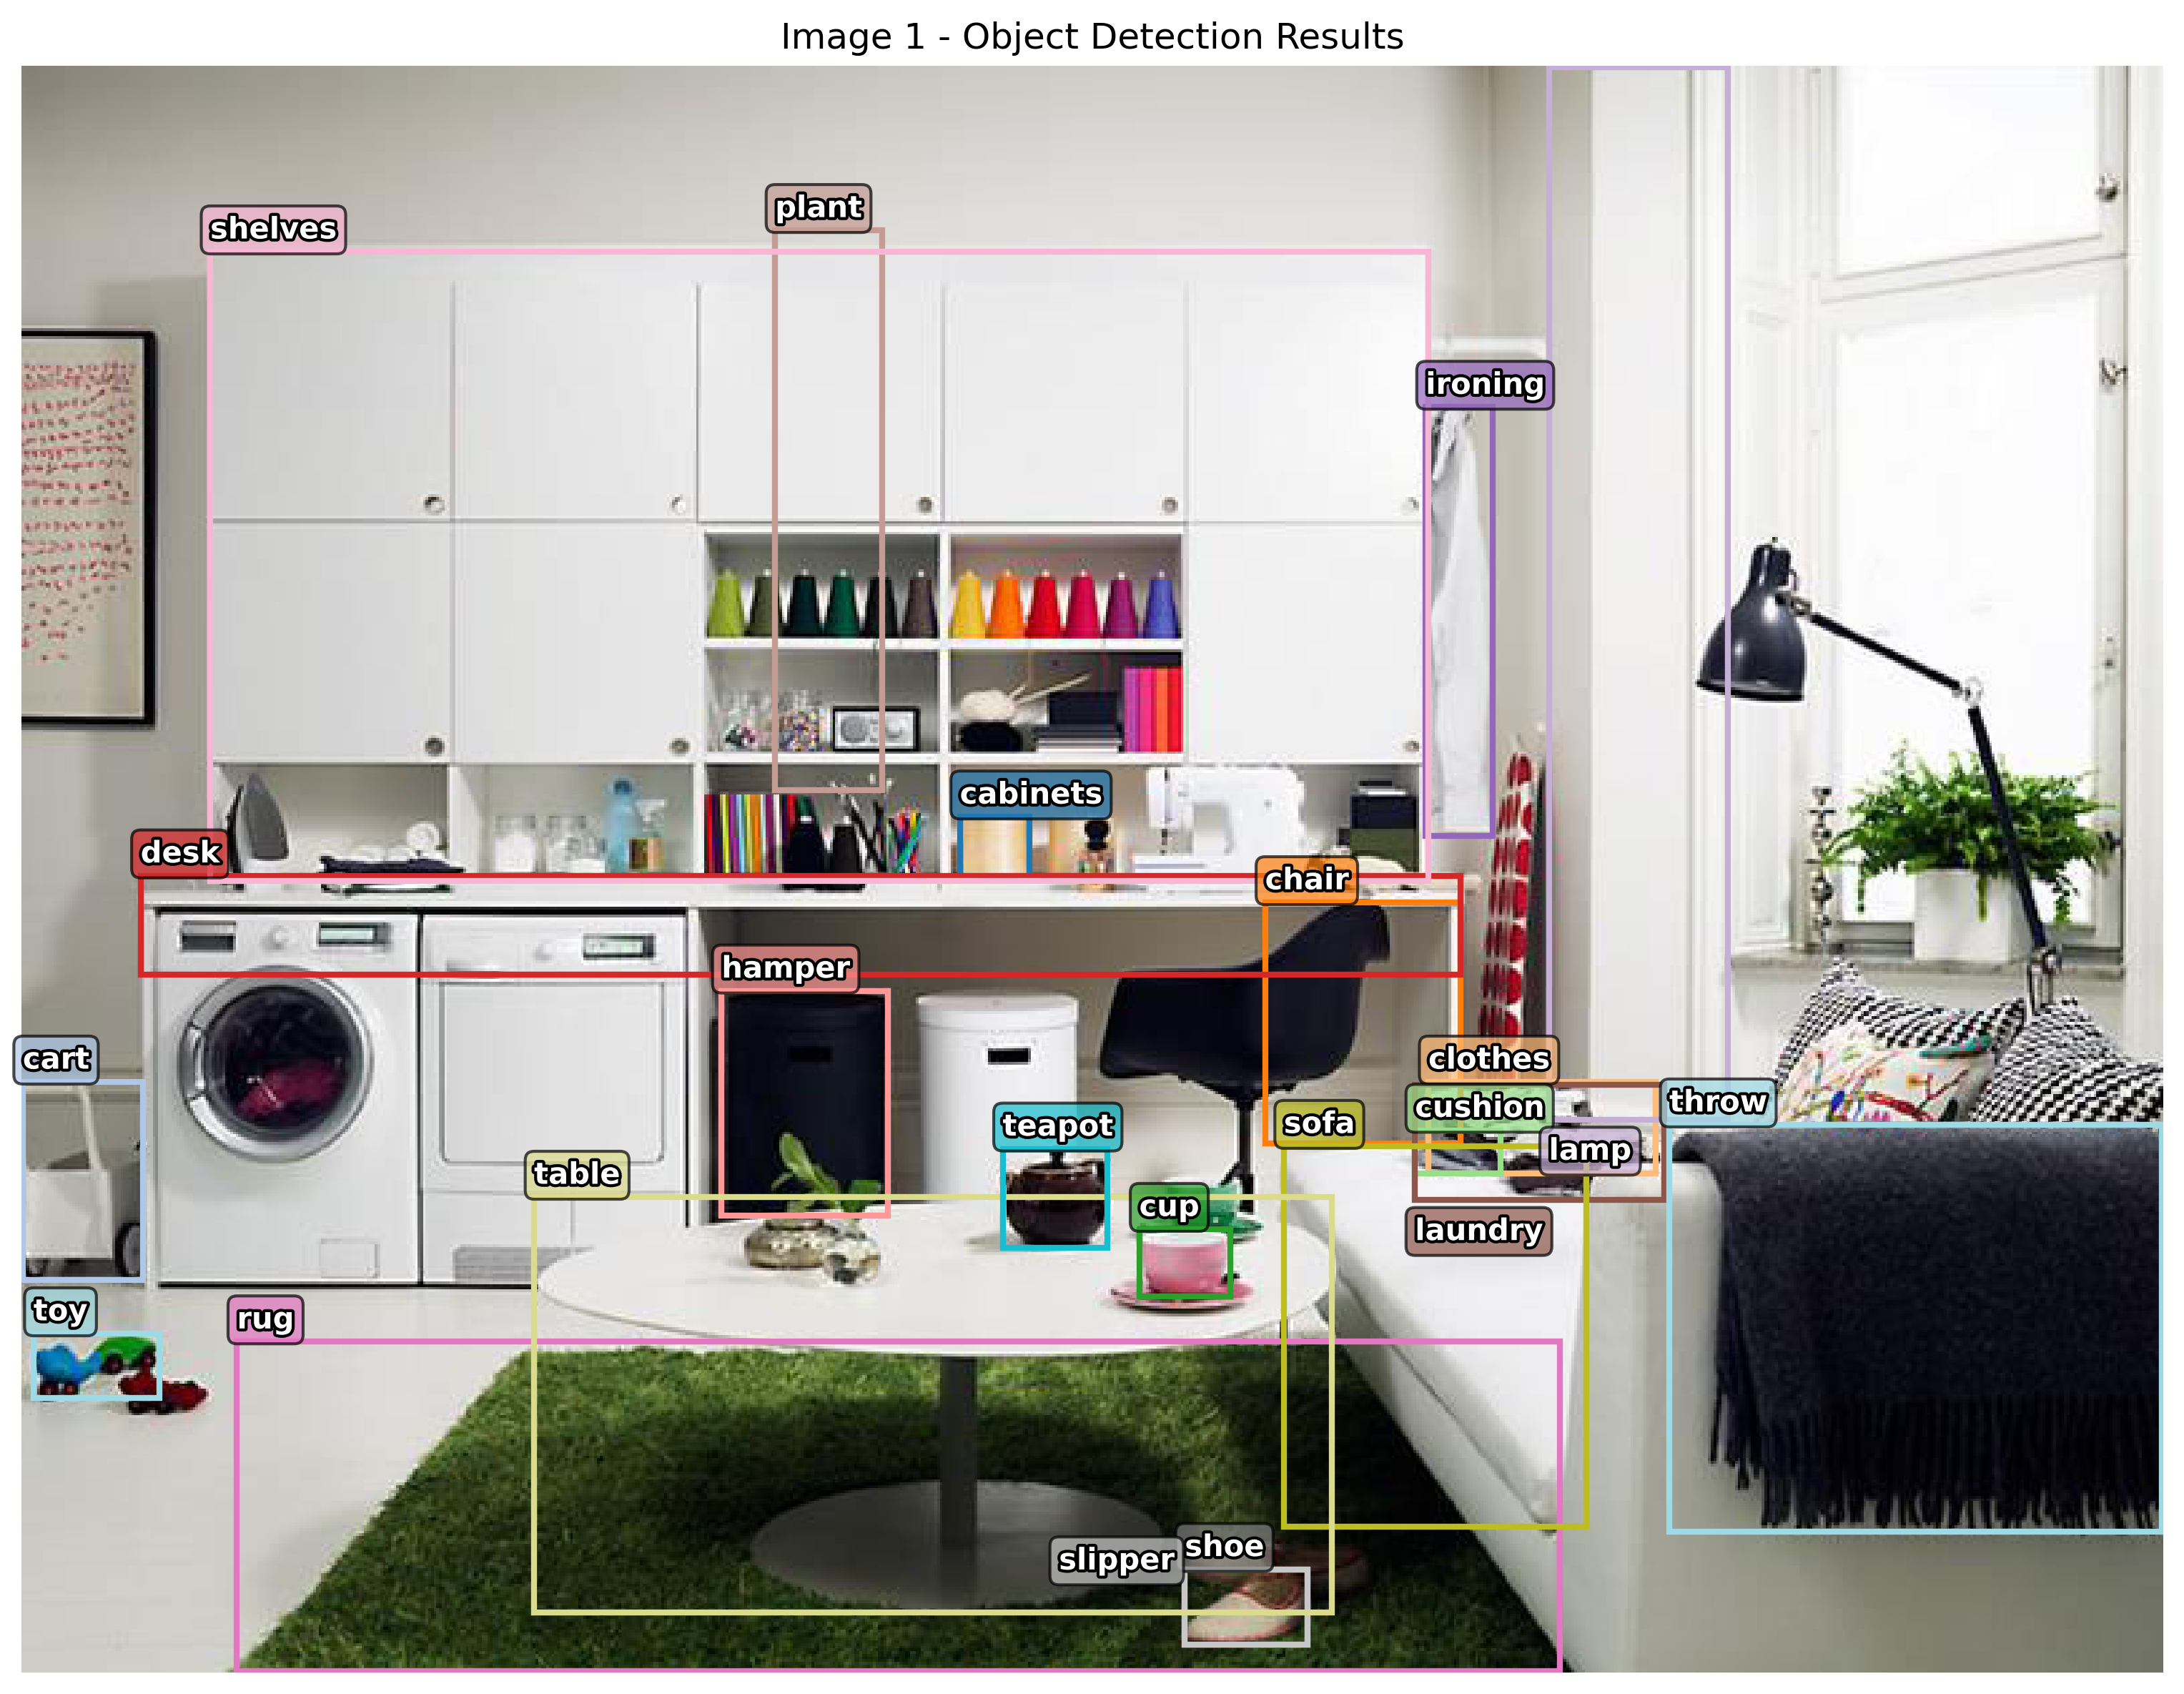

In [7]:
image_data.plot_mask_labels(  );

### Checking the bounding boxes for 1 participant only

In [8]:
IMG_ID = 1
IMG_TYPE = "exp"
llm_provider = "openai"

# load image
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")
#image_data = load_image_data(IMG_PATH, IMG_TYPE)


# load masks
#masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")
#image_data.load_img_masks( masks_path_dir, part_id="2" )        # change here
#print(f"Loaded a total of {len(image_data.masks)} Masks for IMG {image_data.ID}_{image_data.img_type}")

In [9]:
#image_data.get_scene_masks()

In [10]:
#image_data.plot_mask_labels(  );

### KG

In [11]:
# call the KG builder
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG = KnowledgeGraph(llm, image_data)

Disambiguating scene masks...
  -> Lemma match! Removing 'slippers', keeping 'slipper'
  -> Lemma match! Removing 'toys', keeping 'toy'

Plural/duplicate pairs found: [('slipper', 'slippers', 'kept: slipper'), ('toy', 'toys', 'kept: toy')]
Final unique labels: ['cabinets', 'cart', 'chair', 'clothes', 'cup', 'cushion', 'desk', 'hamper', 'ironing', 'lamp', 'laundry', 'plant', 'rug', 'shelves', 'shoe', 'slipper', 'sofa', 'table', 'teapot', 'throw', 'toy']


Processing knowledge graph for image 1


Generating triples for iteration 1...
Scene description completed in 15.56 seconds
Text query completed in 5.30 seconds

Total triples generated: 35


Generating triples for iteration 2...
Scene description completed in 20.56 seconds
Text query completed in 5.97 seconds

Total triples generated: 36


Generating triples for iteration 3...
Scene description completed in 18.02 seconds
Text query completed in 6.66 seconds

Total triples generated: 35

Generated triples: 106
Generated triples after removing duplicates:  45
Professional knowledge graph saved to outputs\KnowledgeGraph\1_knowledge_graph_professional.png
PDF version saved to outputs\KnowledgeGraph\1_knowledge_graph_professional.pdf


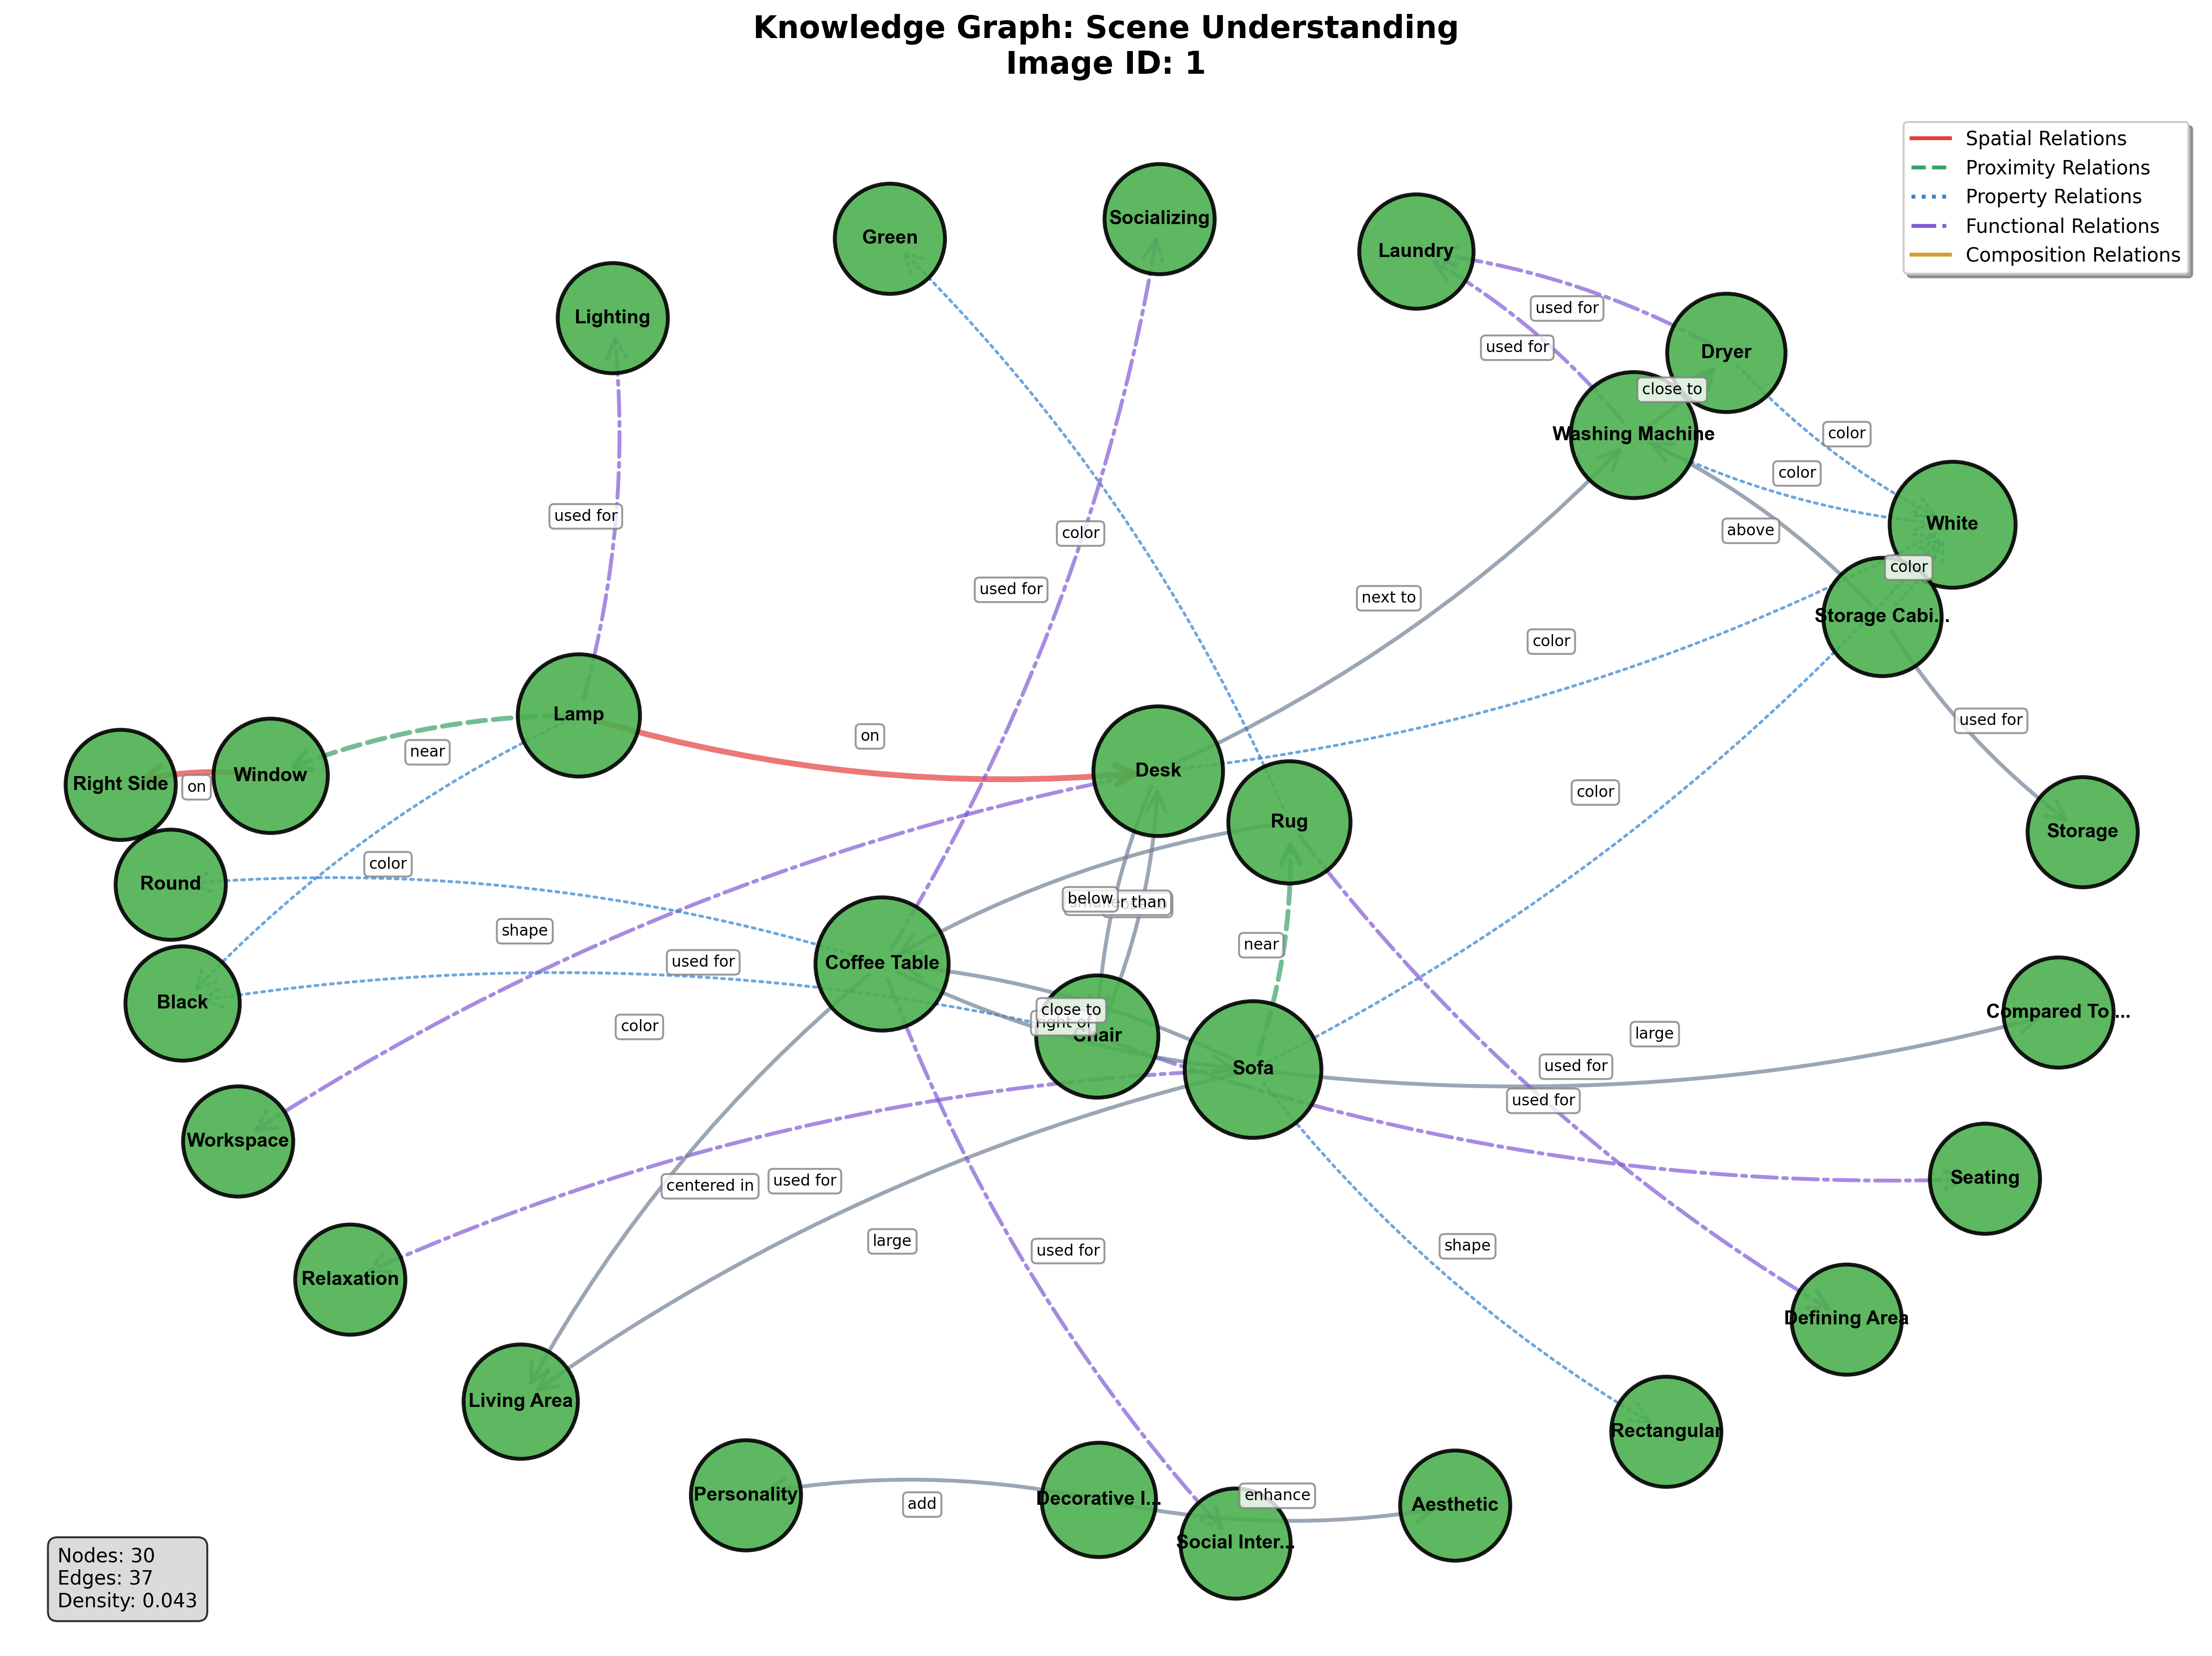

Relationship matrix saved to outputs\KnowledgeGraph\knowledge_matrices\IMG_1_exp_knowledge_matrix.png


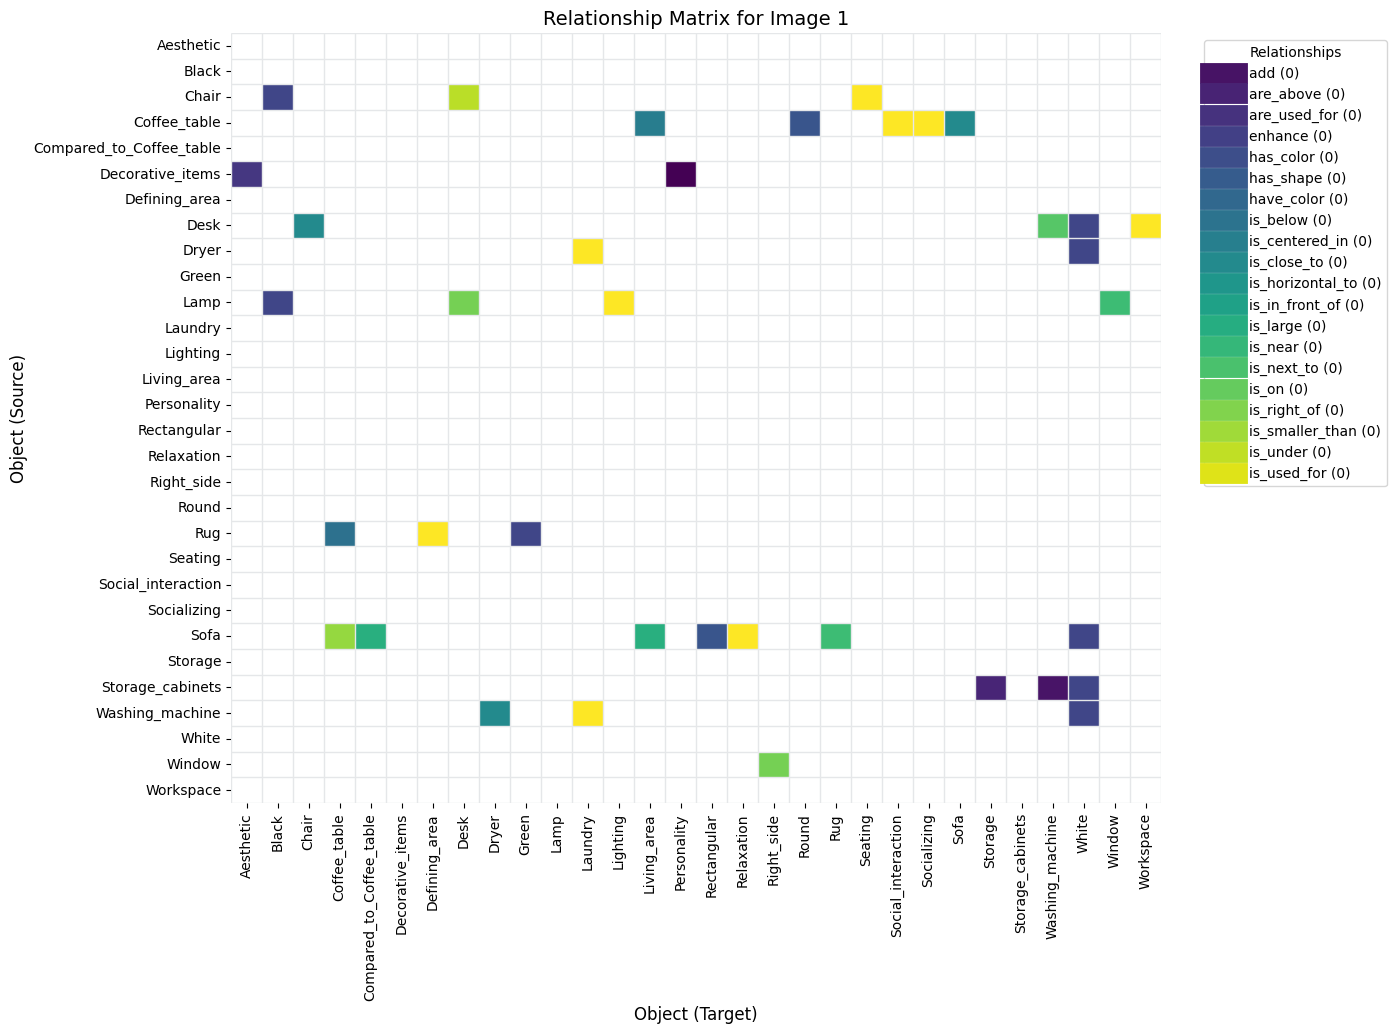

Adjacency matrix saved to outputs\KnowledgeGraph\knowledge_matrices\IMG_1_exp_adjacency_matrix.csv


In [12]:
results = KG.process_image_complete( num_iter=3, debug=False)

In [ ]:

# loading a saved KG
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG2 = KnowledgeGraph(llm, image_data)
KG2.load_state(filepath = "outputs\\KnowledgeGraph\\IMG_1_exp_knowledge_graph.pkl")

Disambiguating scene masks...
  -> Lemma match! Removing 'slippers', keeping 'slipper'
  -> Lemma match! Removing 'toys', keeping 'toy'

Plural/duplicate pairs found: [('slipper', 'slippers', 'kept: slipper'), ('toy', 'toys', 'kept: toy')]
Final unique labels: ['cabinets', 'cart', 'chair', 'clothes', 'cup', 'cushion', 'desk', 'hamper', 'ironing', 'lamp', 'laundry', 'plant', 'rug', 'shelves', 'shoe', 'slipper', 'sofa', 'table', 'teapot', 'throw', 'toy']


Professional knowledge graph saved to outputs\KnowledgeGraph\1_knowledge_graph_professional.png
PDF version saved to outputs\KnowledgeGraph\1_knowledge_graph_professional.pdf


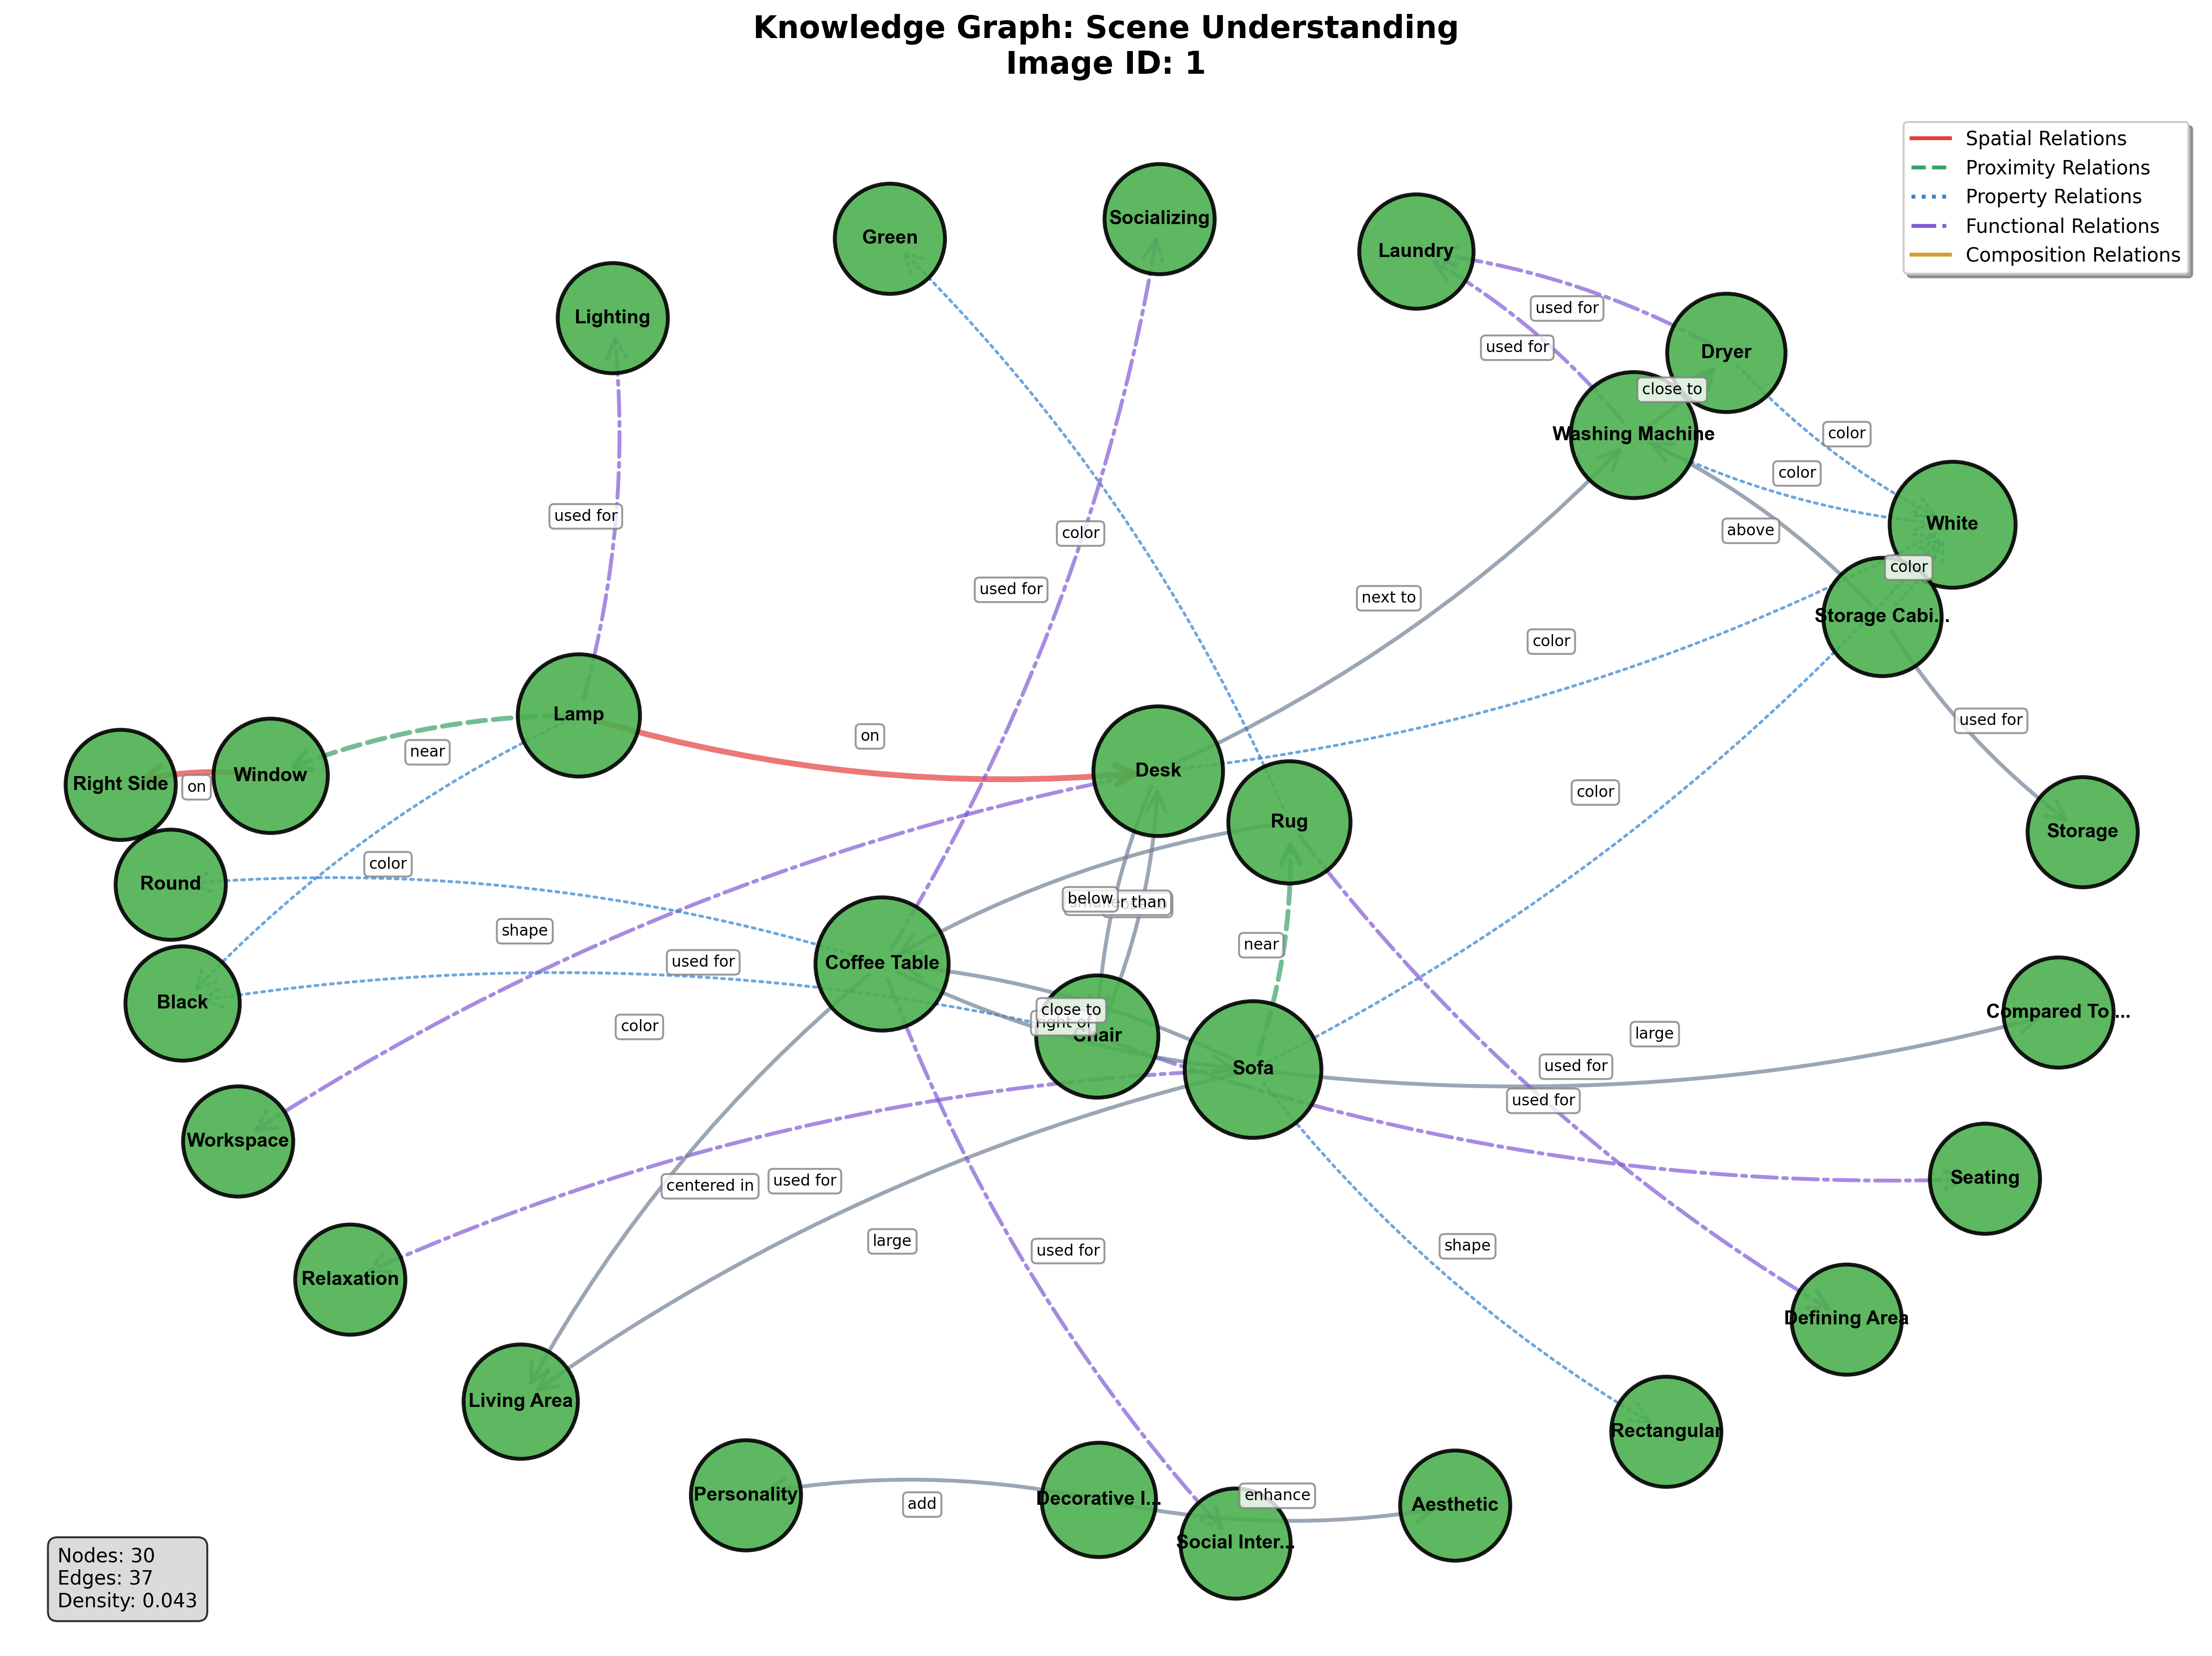

In [16]:
KG2.plot_knowledge_graph()

In [ ]:
# this is part of what the KG.process_image_complete( num_iter=3, debug=False) function is doing.

# running this 3x so we can get a more enriched KG
all_triples = []
for i in range(3):

    print(f"Generating triples for iteration {i + 1}...")
    triples_raw = KG.generate_triples(debug=False)  
    triples_cleaned = KG.clean_triples_text(triples_raw)
    lines = triples_cleaned.strip().split('\n')
    print("\nTotal triples generated:", str(len(lines)))

    for line in lines:
        # Remove parentheses and spaces, then split by comma
        triple = tuple(item.strip().replace('(', '').replace(')', '') for item in line.split(','))
        all_triples.append(triple)

print("\nGenerated triples:", str(len(all_triples)))
# Remove duplicates
triples_final = list(set(all_triples))
print("Generated triples after removing duplicates: ", str(len(triples_final)))